In [1]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *pkgs])

required = ['tensorflow', 'lightgbm', 'xgboost', 'scikit-learn', 'joblib', 'seaborn']
installed = {p.split('==')[0] for p in subprocess.check_output(
    [sys.executable,'-m','pip','list','--format=columns'], text=True).split()}

for pkg in required:
    name = pkg.replace('-','_')
    if name not in installed and pkg not in installed:
        print(f'Installing {pkg}...')
        pip_install(pkg)

import tensorflow as tf
import lightgbm as lgb
import xgboost  as xgb
import sklearn
print(f'TensorFlow : {tf.__version__}')
print(f'LightGBM   : {lgb.__version__}')
print(f'XGBoost    : {xgb.__version__}')
print(f'sklearn    : {sklearn.__version__}')
print('All dependencies ready.')

TensorFlow : 2.19.0
LightGBM   : 4.6.0
XGBoost    : 3.2.0
sklearn    : 1.8.0
All dependencies ready.


In [2]:
import os, json, pickle, warnings, datetime, joblib
import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import seaborn              as sns

import tensorflow            as tf
from tensorflow              import keras
from tensorflow.keras        import layers, regularizers
from tensorflow.keras.callbacks import Callback

import lightgbm  as lgb
import xgboost   as xgb

from sklearn.linear_model    import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble        import (GradientBoostingRegressor, RandomForestRegressor,
                                     GradientBoostingClassifier, RandomForestClassifier)
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler, MinMaxScaler
from sklearn.metrics         import (mean_absolute_error, mean_squared_error, r2_score,
                                     accuracy_score, f1_score, classification_report,
                                     confusion_matrix)

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

TARGET_MAE    = 0.02
TARGET_ACC    = 0.85
N_CLASSES     = 3
DIRECTION_MAP = {'Down': 0, 'Stable': 1, 'Up': 2}
INV_DIR       = {0: 'Down', 1: 'Stable', 2: 'Up'}

SAVED_DIR  = os.path.join('.', 'outputs', 'saved_model')
CHARTS_DIR = os.path.join('.', 'outputs', 'charts')
TB_DIR     = os.path.join('.', 'logs',    'tensorboard')
API_DIR    = os.path.join('.', 'api')
for d in [SAVED_DIR, CHARTS_DIR, TB_DIR, API_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
print('Imports OK.')

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Imports OK.


In [3]:
TRAIN_FILE = 'income_train.csv'
VAL_FILE   = 'income_val.csv'
TEST_FILE  = 'income_test.csv'

df_train = pd.read_csv(TRAIN_FILE)
df_val   = pd.read_csv(VAL_FILE)
df_test  = pd.read_csv(TEST_FILE)

USER_COL   = 'respondent_id'
WEEK_COL   = 'target_idx'
INCOME_COL = 'current_income'
TARGET_REG = 'next_week_income'
TARGET_CLS = 'next_week_direction'

col_aliases = {
    'respondent_id'   : ['respondent_id','user_id','id','synthetic_user_id','source_respondent_id'],
    'target_idx'      : ['target_idx','week_number','week','weeks_observed','target_week_index'],
    'current_income'  : ['current_income','income_amount','income','lag_1_income'],
    'next_week_income': ['next_week_income','target_income','next_income'],
}
for canonical, aliases in col_aliases.items():
    found = next((c for c in aliases if c in df_train.columns), None)
    if found and found != canonical:
        for df in [df_train, df_val, df_test]:
            df.rename(columns={found: canonical}, inplace=True)

for df in [df_train, df_val, df_test]:
    if USER_COL in df.columns and WEEK_COL in df.columns:
        df.sort_values([USER_COL, WEEK_COL], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f'Train : {df_train.shape}')
print(f'Val   : {df_val.shape}')
print(f'Test  : {df_test.shape}')
print(f'Kolom : {df_train.shape[1]}')

Train : (100800, 69)
Val   : (21600, 69)
Test  : (21600, 69)
Kolom : 69


In [4]:
LEAKAGE_COLS = {
    TARGET_REG, TARGET_CLS,
    'monthly_income','avg_weekly_income','income_std_4w',
    'income_cv_4w','income_range_4w','synthetic_weekly_income',
    'next_week_direction',
}
ID_COLS = {USER_COL,'user_id','id','week_start_date','week_end_date',
           'date','dataset_type','week_end','week_start'}

INCOME_COLS_TO_SCALE = [
    c for c in ['current_income','lag_1_income','lag_2_income','lag_3_income',
                 'rolling_mean_income','rolling_std_income','rolling_min_income',
                 'rolling_max_income','rolling_median_income','income_trend_abs',
                 'bps_jasa_weekly']
    if c in df_train.columns
]

FEATURE_COLS = [
    c for c in df_train.columns
    if c not in LEAKAGE_COLS
    and c not in ID_COLS
    and df_train[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]

hard_leak = [c for c in FEATURE_COLS if c in LEAKAGE_COLS]
assert not hard_leak, f'LEAKAGE DETECTED: {hard_leak}'

print(f'Total kolom         : {df_train.shape[1]}')
print(f'Fitur dipakai       : {len(FEATURE_COLS)}')
print(f'INCOME_COLS_TO_SCALE: {INCOME_COLS_TO_SCALE}')
print('Anti-leakage PASSED.')

Total kolom         : 69
Fitur dipakai       : 59
INCOME_COLS_TO_SCALE: ['current_income', 'lag_2_income', 'lag_3_income', 'bps_jasa_weekly']
Anti-leakage PASSED.


In [5]:
income_scaler = MinMaxScaler()
if INCOME_COLS_TO_SCALE:
    income_scaler.fit(df_train[INCOME_COLS_TO_SCALE].fillna(0))
    for df in [df_train, df_val, df_test]:
        df[INCOME_COLS_TO_SCALE] = income_scaler.transform(df[INCOME_COLS_TO_SCALE].fillna(0))

y_train_raw = df_train[TARGET_REG].values.reshape(-1, 1)
y_val_raw   = df_val[TARGET_REG].values.reshape(-1, 1)
y_test_raw  = df_test[TARGET_REG].values.reshape(-1, 1)

local_target_scaler = MinMaxScaler()
local_target_scaler.fit(y_train_raw)

y_train_reg = local_target_scaler.transform(y_train_raw).flatten().astype(np.float32)
y_val_reg   = local_target_scaler.transform(y_val_raw).flatten().astype(np.float32)
y_test_reg  = local_target_scaler.transform(y_test_raw).flatten().astype(np.float32)

y_train_cls = df_train[TARGET_CLS].map(DIRECTION_MAP).fillna(1).values.astype(np.int32)
y_val_cls   = df_val[TARGET_CLS].map(DIRECTION_MAP).fillna(1).values.astype(np.int32)
y_test_cls  = df_test[TARGET_CLS].map(DIRECTION_MAP).fillna(1).values.astype(np.int32)

X_train_raw = df_train[FEATURE_COLS].fillna(0).values.astype(np.float32)
X_val_raw   = df_val[FEATURE_COLS].fillna(0).values.astype(np.float32)
X_test_raw  = df_test[FEATURE_COLS].fillna(0).values.astype(np.float32)

feature_scaler = StandardScaler()
feature_scaler.fit(X_train_raw)

X_train_sc = feature_scaler.transform(X_train_raw).astype(np.float32)
X_val_sc   = feature_scaler.transform(X_val_raw).astype(np.float32)
X_test_sc  = feature_scaler.transform(X_test_raw).astype(np.float32)

y_train_log = np.log1p(y_train_raw.flatten())
y_val_log   = np.log1p(y_val_raw.flatten())
y_test_log  = np.log1p(y_test_raw.flatten())

print(f'X_train_raw : {X_train_raw.shape}')
print(f'X_val_raw   : {X_val_raw.shape}')
print(f'X_test_raw  : {X_test_raw.shape}')
print(f'X_train_sc  : {X_train_sc.shape}')
print(f'y_train_reg : [{y_train_reg.min():.4f}, {y_train_reg.max():.4f}]')
print(f'y_val_reg   : [{y_val_reg.min():.4f}, {y_val_reg.max():.4f}]')
print(f'y_test_reg  : [{y_test_reg.min():.4f}, {y_test_reg.max():.4f}]')
print('Preprocessing complete.')

X_train_raw : (100800, 59)
X_val_raw   : (21600, 59)
X_test_raw  : (21600, 59)
X_train_sc  : (100800, 59)
y_train_reg : [0.0000, 1.0000]
y_val_reg   : [-0.0000, 1.0000]
y_test_reg  : [0.0001, 1.0000]
Preprocessing complete.


In [6]:
class ResidualBlock(layers.Layer):
    def __init__(self, units, dropout=0.2, l2_reg=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.units = units; self.dropout = dropout; self.l2_reg = l2_reg
        reg = regularizers.l2(l2_reg)
        self.dense1  = layers.Dense(units, kernel_regularizer=reg)
        self.bn1     = layers.BatchNormalization()
        self.act1    = layers.Activation('relu')
        self.drop1   = layers.Dropout(dropout)
        self.dense2  = layers.Dense(units, kernel_regularizer=reg)
        self.bn2     = layers.BatchNormalization()
        self.drop2   = layers.Dropout(dropout)
        self.proj    = layers.Dense(units, use_bias=False)
        self.bn_proj = layers.BatchNormalization()
        self.add     = layers.Add()
        self.act_out = layers.Activation('relu')

    def call(self, x, training=False):
        h = self.drop1(self.act1(self.bn1(self.dense1(x), training=training)), training=training)
        h = self.drop2(self.bn2(self.dense2(h), training=training), training=training)
        s = self.bn_proj(self.proj(x), training=training)
        return self.act_out(self.add([h, s]))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units, 'dropout': self.dropout, 'l2_reg': self.l2_reg})
        return cfg


class HuberMAELoss(keras.losses.Loss):
    def __init__(self, delta=0.05, alpha=0.6, name='huber_mae_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.delta = delta; self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
        err    = tf.abs(y_true - y_pred)
        huber  = tf.where(err <= self.delta,
                          0.5 * tf.square(err),
                          self.delta * (err - 0.5 * self.delta))
        return self.alpha * tf.reduce_mean(huber) + (1 - self.alpha) * tf.reduce_mean(err)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'delta': self.delta, 'alpha': self.alpha})
        return cfg


class TensorBoardLogger(Callback):
    def __init__(self, log_dir='./logs/tensorboard'):
        super().__init__()
        self.log_dir = log_dir; self._tw = None; self._vw = None

    def set_model(self, model):
        super().set_model(model)
        self._tw = tf.summary.create_file_writer(os.path.join(self.log_dir, 'train'))
        self._vw = tf.summary.create_file_writer(os.path.join(self.log_dir, 'validation'))

    def on_train_end(self, logs=None):
        if self._tw: self._tw.close()
        if self._vw: self._vw.close()


print('ResidualBlock  ready.')
print('HuberMAELoss   ready.')
print('TensorBoardLogger ready.')

ResidualBlock  ready.
HuberMAELoss   ready.
TensorBoardLogger ready.


In [7]:
def build_fingo_dl(n_features, n_classes=3, units=(256,128,64), dropout=0.25, l2_reg=1e-4):
    reg = regularizers.l2(l2_reg)
    inp = keras.Input(shape=(n_features,), name='features')

    x = layers.Dense(units[0], kernel_regularizer=reg, name='embed')(inp)
    x = layers.BatchNormalization(name='embed_bn')(x)
    x = layers.Activation('relu', name='embed_relu')(x)
    x = layers.Dropout(dropout, name='embed_drop')(x)

    for i, u in enumerate(units):
        x = ResidualBlock(u, dropout=dropout, l2_reg=l2_reg, name=f'res_{i}')(x)

    rh = layers.Dense(64, activation='relu', kernel_regularizer=reg, name='reg_fc1')(x)
    rh = layers.Dropout(dropout / 2, name='reg_drop')(rh)
    rh = layers.Dense(32, activation='relu', kernel_regularizer=reg, name='reg_fc2')(rh)
    income_out = layers.Dense(1, activation='sigmoid', name='income_pred')(rh)

    ch = layers.Dense(64, activation='relu', kernel_regularizer=reg, name='cls_fc1')(x)
    ch = layers.Dropout(dropout / 2, name='cls_drop')(ch)
    ch = layers.Dense(32, activation='relu', kernel_regularizer=reg, name='cls_fc2')(ch)
    dir_out = layers.Dense(n_classes, activation='softmax', name='direction_pred')(ch)

    return keras.Model(inputs=inp, outputs=[income_out, dir_out], name='GigIncomePredictor_v6')


N_FEAT   = X_train_sc.shape[1]
dl_model = build_fingo_dl(N_FEAT, N_CLASSES)
dl_model.summary()
print(f'DL Model: {dl_model.count_params():,} params | Input={N_FEAT} features')

I0000 00:00:1780129520.971029 26248352 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780129520.971184 26248352 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "GigIncomePredictor_v6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 59)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Dense)       │ (None, 256)       │     15,360 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_bn            │ (None, 256)       │      1,024 │ embed[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_relu          │ (None, 256)       │          0 │ embed_bn[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_drop          │ (None, 256)       │          0 │ embed_relu[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_0               │ (None, 256)       │    200,192 │ embed_drop[0][0]  │
│ (ResidualBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_1               │ (None, 128)       │     83,712 │ res_0[0][0]       │
│ (ResidualBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2               │ (None, 64)        │     21,376 │ res_1[0][0]       │
│ (ResidualBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_fc1 (Dense)     │ (None, 64)        │      4,160 │ res_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_fc1 (Dense)     │ (None, 64)        │      4,160 │ res_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_drop (Dropout)  │ (None, 64)        │          0 │ reg_fc1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_drop (Dropout)  │ (None, 64)        │          0 │ cls_fc1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_fc2 (Dense)     │ (None, 32)        │      2,080 │ reg_drop[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_fc2 (Dense)     │ (None, 32)        │      2,080 │ cls_drop[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ income_pred (Dense) │ (None, 1)         │         33 │ reg_fc2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ direction_pred      │ (None, 3)         │         99 │ cls_fc2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 334,276 (1.28 MB)

 Trainable params: 331,076 (1.26 MB)

 Non-trainable params: 3,200 (12.50 KB)

DL Model: 334,276 params | Input=59 features


In [8]:
LINEAR_REG_MODELS = {'LinearRegression', 'Ridge'}

baseline_reg_configs = {
    'LinearRegression': Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())]),
    'Ridge'           : Pipeline([('sc', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=6,
        num_leaves=63, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1, verbose=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        min_samples_leaf=10, subsample=0.8,
        loss='absolute_error', random_state=42
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.04,
        subsample=0.85, colsample_bytree=0.85,
        objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0
    ),
    'RandomForest': RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ),
}

baseline_reg_results = {}

print('='*65)
print('TRAINING BASELINE REGRESSION MODELS')
print('='*65)

for name, model_sk in baseline_reg_configs.items():
    model_sk.fit(X_train_raw, y_train_log)
    pred_val_log  = model_sk.predict(X_val_raw)
    pred_test_log = model_sk.predict(X_test_raw)

    pred_val_idr  = np.maximum(np.expm1(pred_val_log),  0)
    pred_test_idr = np.maximum(np.expm1(pred_test_log), 0)

    pred_val_norm  = np.clip(local_target_scaler.transform(pred_val_idr.reshape(-1,1)).flatten(),  0, 1)
    pred_test_norm = np.clip(local_target_scaler.transform(pred_test_idr.reshape(-1,1)).flatten(), 0, 1)

    val_mae  = mean_absolute_error(y_val_reg,  pred_val_norm)
    test_mae = mean_absolute_error(y_test_reg, pred_test_norm)
    rmse     = np.sqrt(mean_squared_error(y_val_reg, pred_val_norm))
    r2       = r2_score(y_val_reg, pred_val_norm)

    baseline_reg_results[name] = {
        'model'         : model_sk,
        'pred_val_norm' : pred_val_norm,
        'pred_test_norm': pred_test_norm,
        'val_mae'       : val_mae,
        'test_mae'      : test_mae,
        'val_rmse'      : rmse,
        'val_r2'        : r2,
    }
    mark = 'v' if val_mae <= TARGET_MAE else ' '
    print(f'  {name:<22} | ValMAE={val_mae:.4f} {mark} | TestMAE={test_mae:.4f} | RMSE={rmse:.4f} | R2={r2:.3f}')

best_sk_reg_name = min(baseline_reg_results, key=lambda n: baseline_reg_results[n]['val_mae'])
print(f'\nBest sklearn regressor: {best_sk_reg_name}  (val_mae={baseline_reg_results[best_sk_reg_name]["val_mae"]:.4f})')

TRAINING BASELINE REGRESSION MODELS
  LinearRegression       | ValMAE=0.0529   | TestMAE=0.0522 | RMSE=0.0846 | R2=0.678
  Ridge                  | ValMAE=0.0529   | TestMAE=0.0522 | RMSE=0.0846 | R2=0.678
  LightGBM               | ValMAE=0.0327   | TestMAE=0.0333 | RMSE=0.0631 | R2=0.821
  GradientBoosting       | ValMAE=0.0236   | TestMAE=0.0238 | RMSE=0.0594 | R2=0.842
  XGBoost                | ValMAE=0.0324   | TestMAE=0.0331 | RMSE=0.0624 | R2=0.825
  RandomForest           | ValMAE=0.0336   | TestMAE=0.0336 | RMSE=0.0638 | R2=0.817

Best sklearn regressor: GradientBoosting  (val_mae=0.0236)


In [9]:
cls_configs = {
    'LogisticRegression': Pipeline([
        ('sc', StandardScaler()),
        ('lr', LogisticRegression(max_iter=500, C=1.0, class_weight='balanced', random_state=42)),
    ]),
    'LightGBM_cls': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        subsample=0.85, colsample_bytree=0.85,
        class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
    ),
    'GradientBoosting_cls': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42
    ),
    'RandomForest_cls': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
}

cls_results = {}

print('='*65)
print('TRAINING BASELINE CLASSIFIERS')
print('='*65)

for name, model_cl in cls_configs.items():
    model_cl.fit(X_train_raw, y_train_cls)
    if hasattr(model_cl, 'predict_proba'):
        prob_val  = model_cl.predict_proba(X_val_raw)
        prob_test = model_cl.predict_proba(X_test_raw)
    else:
        pv = model_cl.predict(X_val_raw)
        pt = model_cl.predict(X_test_raw)
        prob_val  = np.eye(N_CLASSES)[pv]
        prob_test = np.eye(N_CLASSES)[pt]
    pred_val  = np.argmax(prob_val,  axis=1)
    pred_test = np.argmax(prob_test, axis=1)

    val_acc  = accuracy_score(y_val_cls,  pred_val)
    test_acc = accuracy_score(y_test_cls, pred_test)
    val_f1   = f1_score(y_val_cls, pred_val, average='macro', zero_division=0)

    cls_results[name] = {
        'model'    : model_cl,
        'prob_val' : prob_val,
        'prob_test': prob_test,
        'pred_val' : pred_val,
        'pred_test': pred_test,
        'val_acc'  : val_acc,
        'test_acc' : test_acc,
        'val_f1'   : val_f1,
    }
    mark = 'v' if val_acc >= TARGET_ACC else ' '
    print(f'  {name:<28} | ValAcc={val_acc:.4f} {mark} | TestAcc={test_acc:.4f} | MacroF1={val_f1:.4f}')

best_sk_cls_name = max(cls_results, key=lambda n: cls_results[n]['val_acc'])
print(f'\nBest sklearn classifier: {best_sk_cls_name}  (val_acc={cls_results[best_sk_cls_name]["val_acc"]:.4f})')

TRAINING BASELINE CLASSIFIERS
  LogisticRegression           | ValAcc=0.7113   | TestAcc=0.7118 | MacroF1=0.6202
  LightGBM_cls                 | ValAcc=0.7262   | TestAcc=0.7266 | MacroF1=0.6320
  GradientBoosting_cls         | ValAcc=0.8018   | TestAcc=0.7972 | MacroF1=0.6412
  RandomForest_cls             | ValAcc=0.7600   | TestAcc=0.7594 | MacroF1=0.6442

Best sklearn classifier: GradientBoosting_cls  (val_acc=0.8018)


In [10]:
LR         = 3e-4
BATCH_SIZE = 256
MAX_EPOCHS = 150
GRAD_CLIP  = 1.0
W_REG      = 0.7

reg_loss_fn = HuberMAELoss(delta=0.05, alpha=0.6)
cls_loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer   = keras.optimizers.Adam(LR, clipnorm=GRAD_CLIP)

m_tr_mae = keras.metrics.MeanAbsoluteError(name='mae_reg')
m_tr_acc = keras.metrics.SparseCategoricalAccuracy(name='acc_cls')
m_vl_mae = keras.metrics.MeanAbsoluteError(name='val_mae_reg')
m_vl_acc = keras.metrics.SparseCategoricalAccuracy(name='val_acc_cls')

def make_ds(X, yr, yc, bs, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, yr, yc))
    if shuffle: ds = ds.shuffle(min(len(X), 10_000), seed=42)
    return ds.batch(bs).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_train_sc, y_train_reg, y_train_cls, BATCH_SIZE, shuffle=True)
val_ds   = make_ds(X_val_sc,   y_val_reg,   y_val_cls,   BATCH_SIZE)
test_ds  = make_ds(X_test_sc,  y_test_reg,  y_test_cls,  BATCH_SIZE)

RUN_ID       = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
tb_dir       = os.path.join(TB_DIR, RUN_ID)
train_writer = tf.summary.create_file_writer(os.path.join(tb_dir, 'train'))
val_writer   = tf.summary.create_file_writer(os.path.join(tb_dir, 'validation'))

print(f'Datasets: {len(train_ds)} train batches | {len(val_ds)} val batches | {len(test_ds)} test batches')


@tf.function
def train_step(xb, yb_r, yb_c):
    with tf.GradientTape() as tape:
        ip, dp = dl_model(xb, training=True)
        ip     = tf.squeeze(ip, axis=-1)
        l_r    = reg_loss_fn(yb_r, ip)
        l_c    = cls_loss_fn(yb_c, dp)
        l_reg  = tf.add_n(dl_model.losses) if dl_model.losses else 0.0
        loss   = W_REG * l_r + (1.0 - W_REG) * l_c + l_reg
    grads    = tape.gradient(loss, dl_model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, GRAD_CLIP)
    optimizer.apply_gradients(zip(grads, dl_model.trainable_variables))
    m_tr_mae.update_state(yb_r, ip)
    m_tr_acc.update_state(yb_c, dp)
    return loss, l_r, l_c


@tf.function
def val_step(xb, yb_r, yb_c):
    ip, dp = dl_model(xb, training=False)
    ip     = tf.squeeze(ip, axis=-1)
    m_vl_mae.update_state(yb_r, ip)
    m_vl_acc.update_state(yb_c, dp)


history      = {k: [] for k in ['loss','mae','acc','val_mae','val_acc']}
best_val_mae = float('inf')
best_weights = None
patience     = 15
no_improve   = 0

print('GradientTape Training Loop — GigIncomePredictor v6')
print('='*70)

for epoch in range(MAX_EPOCHS):
    for m in [m_tr_mae, m_tr_acc, m_vl_mae, m_vl_acc]:
        m.reset_state()
    epoch_loss = 0.0

    for step, (xb, yr, yc) in enumerate(train_ds):
        loss, l_r, l_c = train_step(xb, yr, yc)
        epoch_loss += float(loss)

    for xb, yr, yc in val_ds:
        val_step(xb, yr, yc)

    tr_mae   = float(m_tr_mae.result())
    tr_acc   = float(m_tr_acc.result())
    vl_mae   = float(m_vl_mae.result())
    vl_acc   = float(m_vl_acc.result())
    avg_loss = epoch_loss / len(train_ds)

    for k, v in zip(['loss','mae','acc','val_mae','val_acc'],
                    [avg_loss, tr_mae, tr_acc, vl_mae, vl_acc]):
        history[k].append(v)

    with train_writer.as_default():
        tf.summary.scalar('loss', avg_loss, step=epoch)
        tf.summary.scalar('mae',  tr_mae,   step=epoch)
        tf.summary.scalar('acc',  tr_acc,   step=epoch)

    with val_writer.as_default():
        tf.summary.scalar('mae', vl_mae, step=epoch)
        tf.summary.scalar('acc', vl_acc, step=epoch)

    new_lr = max(LR * (0.95 ** (epoch // 10)), 1e-6)
    optimizer.learning_rate.assign(new_lr)

    if vl_mae < best_val_mae:
        best_val_mae = vl_mae
        best_weights = [w.numpy().copy() for w in dl_model.weights]
        no_improve   = 0
    else:
        no_improve  += 1

    if (epoch + 1) % 10 == 0 or epoch < 3:
        mark = 'v' if vl_mae <= TARGET_MAE else ' '
        print(f'Ep {epoch+1:3d}/{MAX_EPOCHS} | Loss={avg_loss:.4f} '
              f'| TrainMAE={tr_mae:.4f} Acc={tr_acc:.3f} '
              f'| ValMAE={vl_mae:.4f} {mark} Acc={vl_acc:.3f} | lr={new_lr:.2e}')

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch+1} (patience={patience})')
        break

    if vl_mae <= TARGET_MAE:
        print(f'Target MAE tercapai di epoch {epoch+1}!')

dl_model.set_weights(best_weights)
train_writer.close()
val_writer.close()
print(f'\nBest weights restored. Best Val MAE: {best_val_mae:.4f}  {"ACHIEVED" if best_val_mae <= TARGET_MAE else "not yet"}')

Datasets: 394 train batches | 85 val batches | 85 test batches
GradientTape Training Loop — GigIncomePredictor v6
Ep   1/150 | Loss=0.3912 | TrainMAE=0.1091 Acc=0.724 | ValMAE=0.0475   Acc=0.789 | lr=3.00e-04
Ep   2/150 | Loss=0.3307 | TrainMAE=0.0601 Acc=0.772 | ValMAE=0.0353   Acc=0.791 | lr=3.00e-04
Ep   3/150 | Loss=0.3106 | TrainMAE=0.0492 Acc=0.779 | ValMAE=0.0336   Acc=0.796 | lr=3.00e-04
Ep  10/150 | Loss=0.2917 | TrainMAE=0.0449 Acc=0.783 | ValMAE=0.0305   Acc=0.796 | lr=3.00e-04
Ep  20/150 | Loss=0.5262 | TrainMAE=0.1523 Acc=0.696 | ValMAE=0.1181   Acc=0.787 | lr=2.85e-04
Early stopping at epoch 28 (patience=15)

Best weights restored. Best Val MAE: 0.0294  not yet


In [11]:
def eval_dl(ds, y_reg, y_cls):
    all_pred_reg = []
    all_prob_cls = []
    for xb, _, _ in ds:
        ip, dp = dl_model(xb, training=False)
        ip     = tf.squeeze(ip, axis=-1)
        all_pred_reg.append(ip.numpy())
        all_prob_cls.append(dp.numpy())
    pred_reg = np.clip(np.concatenate(all_pred_reg, axis=0), 0, 1)
    prob_cls = np.concatenate(all_prob_cls, axis=0)
    pred_cls = np.argmax(prob_cls, axis=1)
    mae = mean_absolute_error(y_reg, pred_reg)
    acc = accuracy_score(y_cls, pred_cls)
    f1  = f1_score(y_cls, pred_cls, average='macro', zero_division=0)
    return pred_reg, pred_cls, prob_cls, mae, acc, f1

dl_pred_val_reg,  dl_pred_val_cls,  dl_prob_val_cls,  dl_val_mae,  dl_val_acc,  dl_val_f1  = eval_dl(val_ds,  y_val_reg,  y_val_cls)
dl_pred_test_reg, dl_pred_test_cls, dl_prob_test_cls, dl_test_mae, dl_test_acc, dl_test_f1 = eval_dl(test_ds, y_test_reg, y_test_cls)

print('='*55)
print('DL Model Evaluation')
print('='*55)
print(f'  Val  MAE  : {dl_val_mae:.4f}   {"v" if dl_val_mae  <= TARGET_MAE else " "}  (target <= {TARGET_MAE})')
print(f'  Test MAE  : {dl_test_mae:.4f}')
print(f'  Val  Acc  : {dl_val_acc:.4f}   {"v" if dl_val_acc  >= TARGET_ACC else " "}  (target >= {TARGET_ACC})')
print(f'  Test Acc  : {dl_test_acc:.4f}')
print(f'  Val  F1   : {dl_val_f1:.4f}')

DL Model Evaluation
  Val  MAE  : 0.2111      (target <= 0.02)
  Test MAE  : 0.2055
  Val  Acc  : 0.6852      (target >= 0.85)
  Test Acc  : 0.6865
  Val  F1   : 0.4998


In [12]:
best_sk_reg  = baseline_reg_results[best_sk_reg_name]
sk_pred_val  = best_sk_reg['pred_val_norm']
sk_pred_test = best_sk_reg['pred_test_norm']

print('='*65)
print('REGRESSION ENSEMBLE SEARCH (validation-based)')
print('='*65)

w_candidates   = np.arange(0.0, 1.05, 0.05)
reg_ens_search = []

for w in w_candidates:
    ens_val = np.clip(w * dl_pred_val_reg + (1 - w) * sk_pred_val, 0, 1)
    mae     = mean_absolute_error(y_val_reg, ens_val)
    reg_ens_search.append((round(float(w), 2), mae))

best_w_dl_reg    = min(reg_ens_search, key=lambda x: x[1])[0]
best_ens_reg_mae = min(reg_ens_search, key=lambda x: x[1])[1]

print(f'  {"w_dl":>6} | {"Val MAE":>9}')
for w, mae in reg_ens_search:
    mark = ' <- BEST' if w == best_w_dl_reg else ''
    print(f'  {w:>6.2f} | {mae:>9.4f}{mark}')

print(f'\n  Best DL weight   : {best_w_dl_reg:.2f}')
print(f'  Best Ens Val MAE : {best_ens_reg_mae:.4f}')
print(f'  SK  Val MAE      : {best_sk_reg["val_mae"]:.4f}')
print(f'  DL  Val MAE      : {dl_val_mae:.4f}')

ens_pred_val_reg  = np.clip(best_w_dl_reg * dl_pred_val_reg  + (1 - best_w_dl_reg) * sk_pred_val,  0, 1)
ens_pred_test_reg = np.clip(best_w_dl_reg * dl_pred_test_reg + (1 - best_w_dl_reg) * sk_pred_test, 0, 1)
ens_reg_val_mae   = mean_absolute_error(y_val_reg,  ens_pred_val_reg)
ens_reg_test_mae  = mean_absolute_error(y_test_reg, ens_pred_test_reg)

reg_candidates = {
    best_sk_reg_name: {
        'val_mae'  : best_sk_reg['val_mae'],
        'test_mae' : best_sk_reg['test_mae'],
        'pred_val' : sk_pred_val,
        'pred_test': sk_pred_test,
        'type'     : 'sklearn',
    },
    'DL': {
        'val_mae'  : dl_val_mae,
        'test_mae' : dl_test_mae,
        'pred_val' : dl_pred_val_reg,
        'pred_test': dl_pred_test_reg,
        'type'     : 'dl',
    },
    f'Ens(DL={best_w_dl_reg:.2f}+{best_sk_reg_name})': {
        'val_mae'  : ens_reg_val_mae,
        'test_mae' : ens_reg_test_mae,
        'pred_val' : ens_pred_val_reg,
        'pred_test': ens_pred_test_reg,
        'type'     : 'ensemble',
    },
}

FINAL_REG_NAME = min(reg_candidates, key=lambda n: reg_candidates[n]['val_mae'])
FINAL_REG_TYPE = reg_candidates[FINAL_REG_NAME]['type']

print(f'\n  Final Regression : {FINAL_REG_NAME}  [{FINAL_REG_TYPE}]')
print(f'  Val MAE          : {reg_candidates[FINAL_REG_NAME]["val_mae"]:.4f}  {"v" if reg_candidates[FINAL_REG_NAME]["val_mae"] <= TARGET_MAE else " "}')

REGRESSION ENSEMBLE SEARCH (validation-based)
    w_dl |   Val MAE
    0.00 |    0.0236 <- BEST
    0.05 |    0.0269
    0.10 |    0.0345
    0.15 |    0.0434
    0.20 |    0.0527
    0.25 |    0.0621
    0.30 |    0.0716
    0.35 |    0.0811
    0.40 |    0.0906
    0.45 |    0.1002
    0.50 |    0.1098
    0.55 |    0.1194
    0.60 |    0.1292
    0.65 |    0.1391
    0.70 |    0.1491
    0.75 |    0.1592
    0.80 |    0.1695
    0.85 |    0.1798
    0.90 |    0.1902
    0.95 |    0.2006
    1.00 |    0.2111

  Best DL weight   : 0.00
  Best Ens Val MAE : 0.0236
  SK  Val MAE      : 0.0236
  DL  Val MAE      : 0.2111

  Final Regression : GradientBoosting  [sklearn]
  Val MAE          : 0.0236   


In [13]:
best_sk_cls  = cls_results[best_sk_cls_name]
sk_prob_val  = best_sk_cls['prob_val']
sk_prob_test = best_sk_cls['prob_test']

print('='*65)
print('CLASSIFICATION ENSEMBLE SEARCH (validation-based)')
print('='*65)

cls_ens_search = []
for w in w_candidates:
    ens_prob_val = np.clip(w * dl_prob_val_cls + (1 - w) * sk_prob_val, 0, None)
    ens_prob_val = ens_prob_val / np.maximum(ens_prob_val.sum(axis=1, keepdims=True), 1e-9)
    pred_v       = np.argmax(ens_prob_val, axis=1)
    acc_v        = accuracy_score(y_val_cls, pred_v)
    cls_ens_search.append((round(float(w), 2), acc_v))

best_w_dl_cls    = max(cls_ens_search, key=lambda x: x[1])[0]
best_ens_cls_acc = max(cls_ens_search, key=lambda x: x[1])[1]

print(f'  {"w_dl":>6} | {"Val Acc":>9}')
for w, acc in cls_ens_search:
    mark = ' <- BEST' if w == best_w_dl_cls else ''
    print(f'  {w:>6.2f} | {acc:>9.4f}{mark}')

ens_prob_val_cls  = np.clip(best_w_dl_cls * dl_prob_val_cls  + (1 - best_w_dl_cls) * sk_prob_val,  0, None)
ens_prob_test_cls = np.clip(best_w_dl_cls * dl_prob_test_cls + (1 - best_w_dl_cls) * sk_prob_test, 0, None)
ens_prob_val_cls  = ens_prob_val_cls  / np.maximum(ens_prob_val_cls.sum(axis=1,  keepdims=True), 1e-9)
ens_prob_test_cls = ens_prob_test_cls / np.maximum(ens_prob_test_cls.sum(axis=1, keepdims=True), 1e-9)
ens_cls_val_acc   = accuracy_score(y_val_cls,  np.argmax(ens_prob_val_cls,  axis=1))
ens_cls_test_acc  = accuracy_score(y_test_cls, np.argmax(ens_prob_test_cls, axis=1))
ens_cls_val_f1    = f1_score(y_val_cls, np.argmax(ens_prob_val_cls, axis=1), average='macro', zero_division=0)

cls_candidates = {
    best_sk_cls_name: {
        'val_acc'  : best_sk_cls['val_acc'],  'test_acc': best_sk_cls['test_acc'],
        'val_f1'   : best_sk_cls['val_f1'],
        'pred_val' : best_sk_cls['pred_val'], 'pred_test': best_sk_cls['pred_test'],
        'prob_val' : sk_prob_val,             'prob_test': sk_prob_test,
        'type'     : 'sklearn',
    },
    'DL_cls': {
        'val_acc'  : dl_val_acc,   'test_acc': dl_test_acc,
        'val_f1'   : dl_val_f1,
        'pred_val' : dl_pred_val_cls, 'pred_test': dl_pred_test_cls,
        'prob_val' : dl_prob_val_cls, 'prob_test': dl_prob_test_cls,
        'type'     : 'dl',
    },
    f'Ens_cls(DL={best_w_dl_cls:.2f})': {
        'val_acc'  : ens_cls_val_acc,  'test_acc': ens_cls_test_acc,
        'val_f1'   : ens_cls_val_f1,
        'pred_val' : np.argmax(ens_prob_val_cls, axis=1),
        'pred_test': np.argmax(ens_prob_test_cls, axis=1),
        'prob_val' : ens_prob_val_cls, 'prob_test': ens_prob_test_cls,
        'type'     : 'ensemble',
    },
}

FINAL_CLS_NAME = max(cls_candidates, key=lambda n: cls_candidates[n]['val_acc'])
FINAL_CLS_TYPE = cls_candidates[FINAL_CLS_NAME]['type']

print(f'\n  Final Classifier : {FINAL_CLS_NAME}  [{FINAL_CLS_TYPE}]')
print(f'  Val Acc          : {cls_candidates[FINAL_CLS_NAME]["val_acc"]:.4f}  {"v" if cls_candidates[FINAL_CLS_NAME]["val_acc"] >= TARGET_ACC else " "}')

CLASSIFICATION ENSEMBLE SEARCH (validation-based)
    w_dl |   Val Acc
    0.00 |    0.8018 <- BEST
    0.05 |    0.8008
    0.10 |    0.8000
    0.15 |    0.7991
    0.20 |    0.7975
    0.25 |    0.7953
    0.30 |    0.7915
    0.35 |    0.7838
    0.40 |    0.7724
    0.45 |    0.7560
    0.50 |    0.7043
    0.55 |    0.6985
    0.60 |    0.6948
    0.65 |    0.6931
    0.70 |    0.6907
    0.75 |    0.6900
    0.80 |    0.6887
    0.85 |    0.6875
    0.90 |    0.6866
    0.95 |    0.6858
    1.00 |    0.6852

  Final Classifier : GradientBoosting_cls  [sklearn]
  Val Acc          : 0.8018   


In [14]:
FINAL_PRED_VAL_REG  = reg_candidates[FINAL_REG_NAME]['pred_val']
FINAL_PRED_TEST_REG = reg_candidates[FINAL_REG_NAME]['pred_test']
FINAL_REG_VAL_MAE   = reg_candidates[FINAL_REG_NAME]['val_mae']
FINAL_REG_TEST_MAE  = reg_candidates[FINAL_REG_NAME]['test_mae']

FINAL_PRED_VAL_CLS  = cls_candidates[FINAL_CLS_NAME]['pred_val']
FINAL_PRED_TEST_CLS = cls_candidates[FINAL_CLS_NAME]['pred_test']
FINAL_CLS_VAL_ACC   = cls_candidates[FINAL_CLS_NAME]['val_acc']
FINAL_CLS_TEST_ACC  = cls_candidates[FINAL_CLS_NAME]['test_acc']
FINAL_CLS_VAL_F1    = cls_candidates[FINAL_CLS_NAME]['val_f1']

print('='*65)
print('FINAL MODEL SELECTION')
print('='*65)
print(f'  REGRESSION   : {FINAL_REG_NAME} [{FINAL_REG_TYPE}]')
print(f'  Val  MAE     : {FINAL_REG_VAL_MAE:.4f}  {"v ACHIEVED" if FINAL_REG_VAL_MAE <= TARGET_MAE else "below target"}')
print(f'  Test MAE     : {FINAL_REG_TEST_MAE:.4f}')
print()
print(f'  CLASSIFICATION: {FINAL_CLS_NAME} [{FINAL_CLS_TYPE}]')
print(f'  Val  Acc     : {FINAL_CLS_VAL_ACC:.4f}  {"v ACHIEVED" if FINAL_CLS_VAL_ACC >= TARGET_ACC else "below target"}')
print(f'  Test Acc     : {FINAL_CLS_TEST_ACC:.4f}')
print(f'  Val  F1      : {FINAL_CLS_VAL_F1:.4f}')

FINAL MODEL SELECTION
  REGRESSION   : GradientBoosting [sklearn]
  Val  MAE     : 0.0236  below target
  Test MAE     : 0.0238

  CLASSIFICATION: GradientBoosting_cls [sklearn]
  Val  Acc     : 0.8018  below target
  Test Acc     : 0.7972
  Val  F1      : 0.6412


In [15]:
y_pred_test_clip = np.clip(FINAL_PRED_TEST_REG, 0, 1)
final_test_mae   = mean_absolute_error(y_test_reg, y_pred_test_clip)
final_test_rmse  = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_clip))
final_test_r2    = r2_score(y_test_reg, y_pred_test_clip)

income_min    = float(local_target_scaler.data_min_[0])
income_max    = float(local_target_scaler.data_max_[0])
income_range  = income_max - income_min
final_mae_idr = final_test_mae * income_range

def tolerance_accuracy(y_true, y_pred, tol):
    return (np.abs(y_true - y_pred) < tol).mean() * 100

acc_2pct  = tolerance_accuracy(y_test_reg, y_pred_test_clip, 0.02)
acc_5pct  = tolerance_accuracy(y_test_reg, y_pred_test_clip, 0.05)
acc_10pct = tolerance_accuracy(y_test_reg, y_pred_test_clip, 0.10)

final_test_acc = accuracy_score(y_test_cls, FINAL_PRED_TEST_CLS)
final_test_f1  = f1_score(y_test_cls, FINAL_PRED_TEST_CLS, average='macro', zero_division=0)

w = 70
print('='*w)
print('FINAL TEST EVALUATION')
print('='*w)
print(f'  REGRESSION')
print(f'  MAE  (normalized)    : {final_test_mae:.4f}   {"v ACHIEVED" if final_test_mae <= TARGET_MAE else f"gap={final_test_mae-TARGET_MAE:.4f}"}')
print(f'  RMSE (normalized)    : {final_test_rmse:.4f}')
print(f'  R2                   : {final_test_r2:.4f}')
print(f'  MAE  (Rp)            : Rp {final_mae_idr:,.0f}')
print(f'  Income range         : Rp {income_min:,.0f} - Rp {income_max:,.0f}')
print(f'  Tolerance Acc  <2%   : {acc_2pct:.1f}%')
print(f'  Tolerance Acc  <5%   : {acc_5pct:.1f}%')
print(f'  Tolerance Acc <10%   : {acc_10pct:.1f}%')
print()
print(f'  CLASSIFICATION')
print(f'  Accuracy (test)      : {final_test_acc:.4f}   {"v ACHIEVED" if final_test_acc >= TARGET_ACC else "below target"}')
print(f'  Macro F1 (test)      : {final_test_f1:.4f}')
print()
print('  Classification Report:')
print(classification_report(y_test_cls, FINAL_PRED_TEST_CLS,
                             target_names=['Down','Stable','Up'], zero_division=0))
print()
print('  Model Comparison:')
print(f'  {"Model":<32} {"ValMAE":>8} {"TestMAE":>8}')
print('  '+'-'*50)
for nm, res in baseline_reg_results.items():
    print(f'  {nm:<32} {res["val_mae"]:>8.4f} {res["test_mae"]:>8.4f}')
print(f'  {"DL":<32} {dl_val_mae:>8.4f} {dl_test_mae:>8.4f}')
for rk, rc in reg_candidates.items():
    if rk not in (best_sk_reg_name, 'DL'):
        print(f'  {rk:<32} {rc["val_mae"]:>8.4f} {rc["test_mae"]:>8.4f}')
print('  '+'-'*50)
print(f'  {"[FINAL] "+FINAL_REG_NAME:<32} {FINAL_REG_VAL_MAE:>8.4f} {final_test_mae:>8.4f}   <- FINAL')
print('='*w)

FINAL TEST EVALUATION
  REGRESSION
  MAE  (normalized)    : 0.0238   gap=0.0038
  RMSE (normalized)    : 0.0604
  R2                   : 0.8490
  MAE  (Rp)            : Rp 46,223
  Income range         : Rp 28 - Rp 1,940,300
  Tolerance Acc  <2%   : 77.3%
  Tolerance Acc  <5%   : 89.7%
  Tolerance Acc <10%   : 94.3%

  CLASSIFICATION
  Accuracy (test)      : 0.7972   below target
  Macro F1 (test)      : 0.6372

  Classification Report:
              precision    recall  f1-score   support

        Down       0.66      0.20      0.31      2547
      Stable       0.80      0.95      0.87     13976
          Up       0.81      0.67      0.74      5077

    accuracy                           0.80     21600
   macro avg       0.76      0.61      0.64     21600
weighted avg       0.79      0.80      0.77     21600


  Model Comparison:
  Model                              ValMAE  TestMAE
  --------------------------------------------------
  LinearRegression                   0.0529   0.052

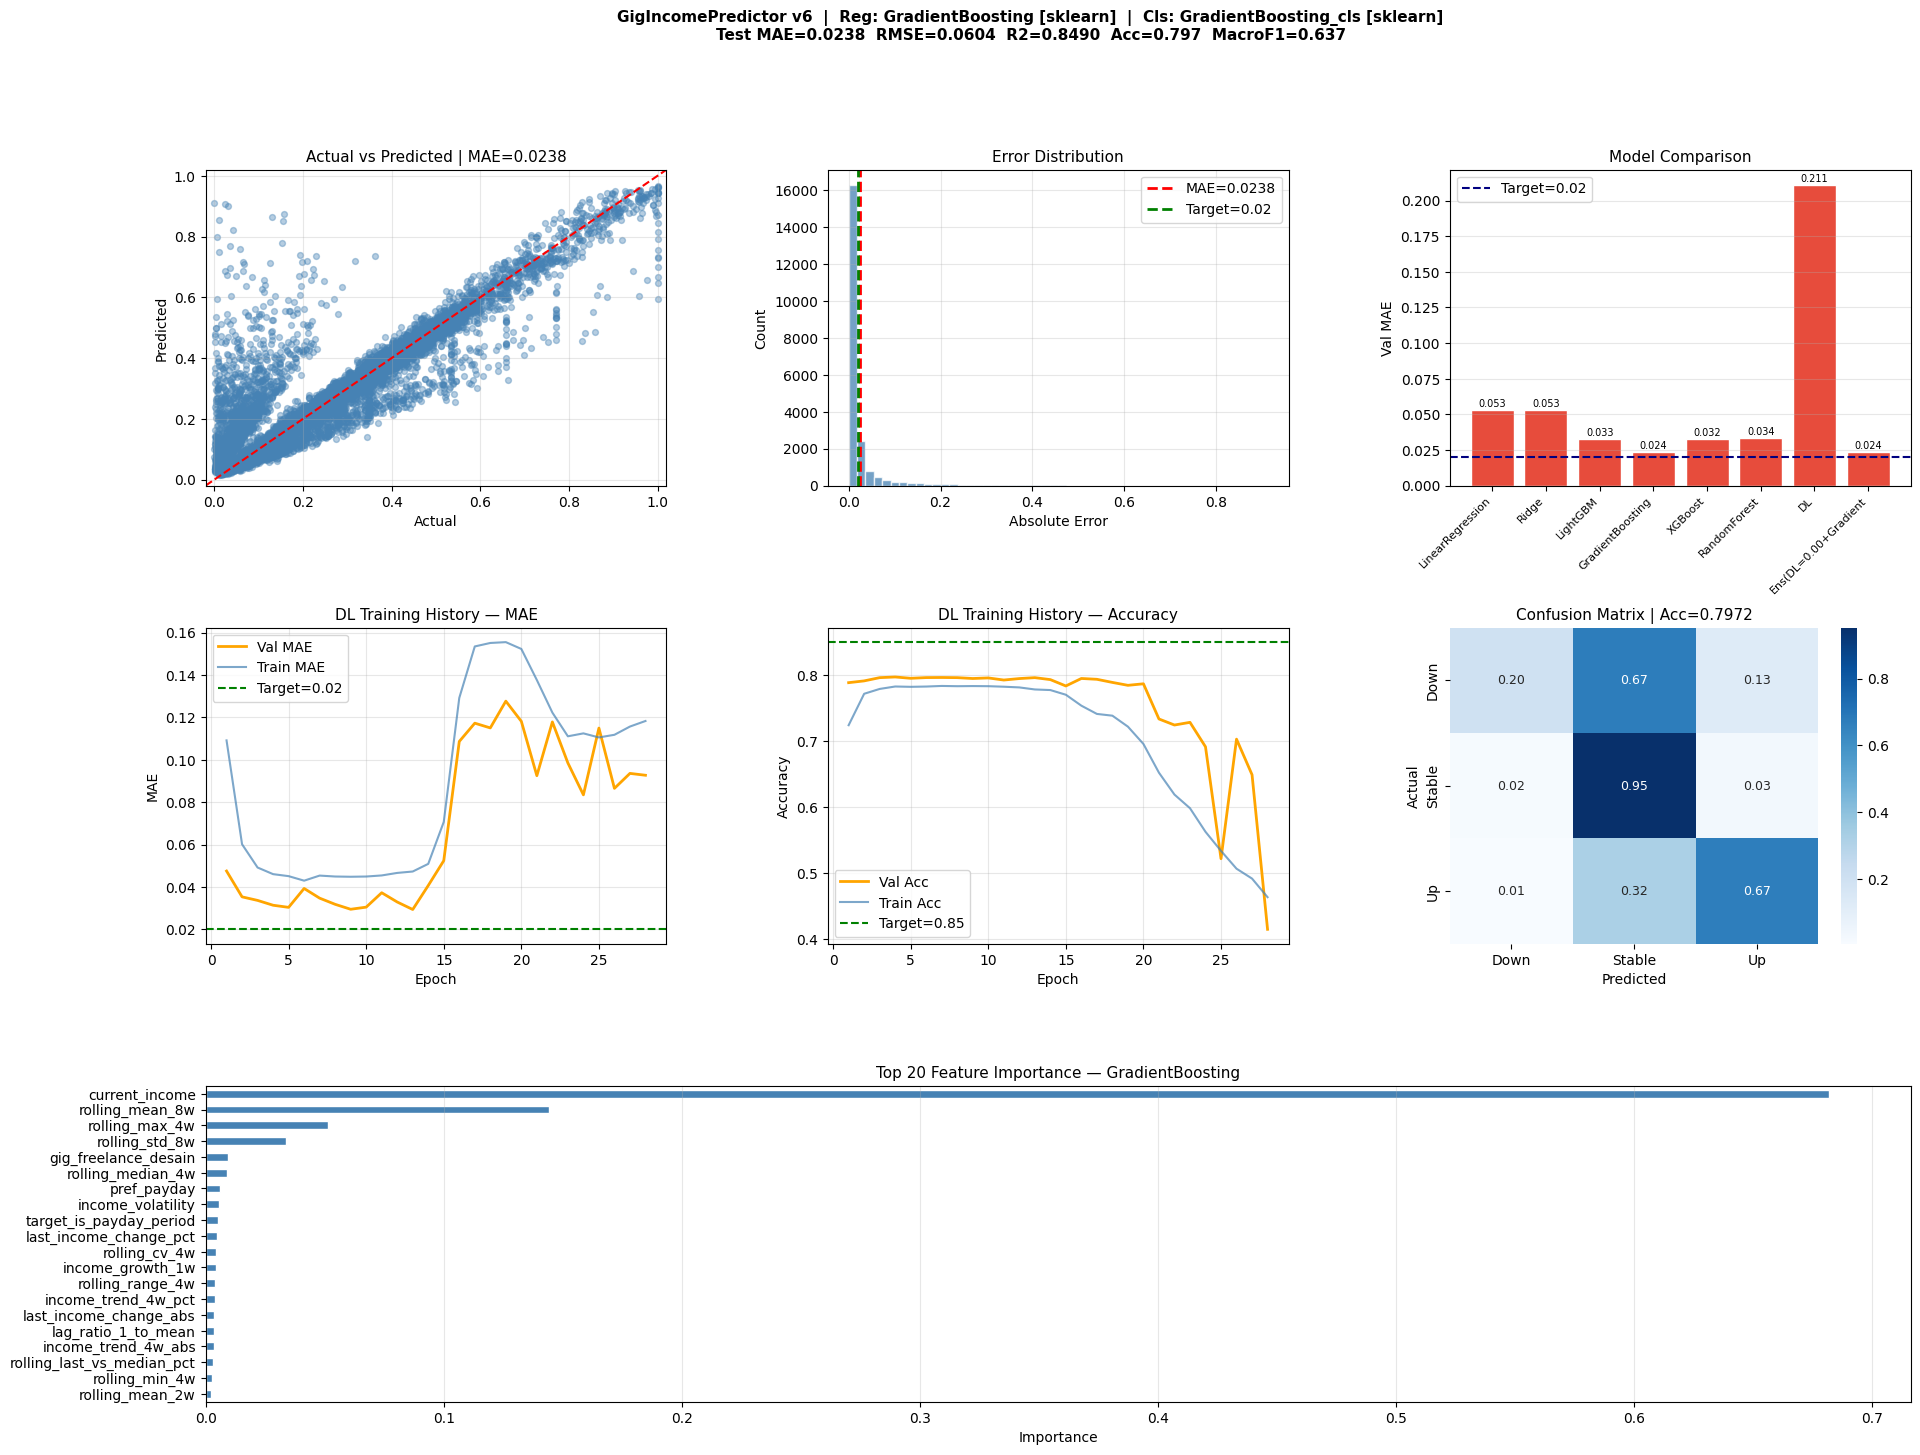

Chart saved: ./outputs/charts/v6_evaluation_full.png


In [16]:
fig = plt.figure(figsize=(22, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

y_pred_final = np.clip(FINAL_PRED_TEST_REG, 0, 1)
errors_test  = np.abs(y_test_reg - y_pred_final)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test_reg, y_pred_final, alpha=0.4, s=18, color='steelblue')
lim = [-0.02, 1.02]
ax1.plot(lim, lim, 'r--', linewidth=1.5)
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel('Actual'); ax1.set_ylabel('Predicted')
ax1.set_title(f'Actual vs Predicted | MAE={final_test_mae:.4f}', fontsize=11)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(errors_test, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
ax2.axvline(final_test_mae, color='red',   linestyle='--', linewidth=2, label=f'MAE={final_test_mae:.4f}')
ax2.axvline(TARGET_MAE,     color='green', linestyle='--', linewidth=2, label=f'Target={TARGET_MAE}')
ax2.set_xlabel('Absolute Error'); ax2.set_ylabel('Count')
ax2.set_title('Error Distribution', fontsize=11)
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
names_bar = list(baseline_reg_results.keys()) + ['DL']
maes_bar  = [baseline_reg_results[n]['val_mae'] for n in baseline_reg_results] + [dl_val_mae]
for rk, rc in reg_candidates.items():
    if rk not in (best_sk_reg_name, 'DL'):
        names_bar.append(rk[:20])
        maes_bar.append(rc['val_mae'])
colors_bar = ['#2ecc71' if m <= TARGET_MAE else '#e74c3c' for m in maes_bar]
bars = ax3.bar(range(len(names_bar)), maes_bar, color=colors_bar, edgecolor='white')
ax3.axhline(TARGET_MAE, color='navy', linestyle='--', linewidth=1.5, label=f'Target={TARGET_MAE}')
ax3.set_xticks(range(len(names_bar)))
ax3.set_xticklabels(names_bar, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Val MAE')
ax3.set_title('Model Comparison', fontsize=11)
ax3.legend(); ax3.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, maes_bar):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f'{v:.3f}',
             ha='center', va='bottom', fontsize=7)

ax4 = fig.add_subplot(gs[1, 0])
ep  = range(1, len(history['mae'])+1)
ax4.plot(ep, history['val_mae'], label='Val MAE',   color='orange',    linewidth=2)
ax4.plot(ep, history['mae'],     label='Train MAE', color='steelblue', linewidth=1.5, alpha=0.7)
ax4.axhline(TARGET_MAE, color='green', linestyle='--', linewidth=1.5, label=f'Target={TARGET_MAE}')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('MAE')
ax4.set_title('DL Training History — MAE', fontsize=11)
ax4.legend(); ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(ep, history['val_acc'], label='Val Acc',   color='orange',    linewidth=2)
ax5.plot(ep, history['acc'],     label='Train Acc', color='steelblue', linewidth=1.5, alpha=0.7)
ax5.axhline(TARGET_ACC, color='green', linestyle='--', linewidth=1.5, label=f'Target={TARGET_ACC}')
ax5.set_xlabel('Epoch'); ax5.set_ylabel('Accuracy')
ax5.set_title('DL Training History — Accuracy', fontsize=11)
ax5.legend(); ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
cm_mat = confusion_matrix(y_test_cls, FINAL_PRED_TEST_CLS)
cm_norm = cm_mat.astype(float) / np.maximum(cm_mat.sum(axis=1, keepdims=True), 1)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax6,
            xticklabels=['Down','Stable','Up'], yticklabels=['Down','Stable','Up'],
            annot_kws={'size': 9})
ax6.set_title(f'Confusion Matrix | Acc={final_test_acc:.4f}', fontsize=11)
ax6.set_xlabel('Predicted'); ax6.set_ylabel('Actual')

ax7 = fig.add_subplot(gs[2, :])
tree_models = {n: baseline_reg_results[n]['model']
               for n in baseline_reg_results
               if hasattr(baseline_reg_results[n]['model'], 'feature_importances_')}
if tree_models:
    best_tree_name = min(tree_models, key=lambda n: baseline_reg_results[n]['val_mae'])
    fi_model = tree_models[best_tree_name]
    if hasattr(fi_model, 'named_steps'):
        fi_model = list(fi_model.named_steps.values())[-1]
    fi = pd.Series(fi_model.feature_importances_, index=FEATURE_COLS).nlargest(20)
    fi.plot(kind='barh', ax=ax7, color='steelblue', edgecolor='white')
    ax7.invert_yaxis()
    ax7.set_title(f'Top 20 Feature Importance — {best_tree_name}', fontsize=11)
    ax7.set_xlabel('Importance'); ax7.grid(True, alpha=0.3, axis='x')
else:
    sorted_idx = np.argsort(errors_test)
    ax7.bar(range(len(errors_test)), errors_test[sorted_idx], color='steelblue', alpha=0.6, width=1.0)
    ax7.axhline(TARGET_MAE,     color='red',    linestyle='--', linewidth=1.5, label=f'Target={TARGET_MAE}')
    ax7.axhline(final_test_mae, color='orange', linestyle='--', linewidth=1.5, label=f'Mean={final_test_mae:.4f}')
    ax7.set_xlabel('Sample (sorted by error)'); ax7.set_ylabel('Absolute Error')
    ax7.set_title('Per-Sample Absolute Error (sorted)', fontsize=11)
    ax7.legend(); ax7.grid(True, alpha=0.3)

plt.suptitle(
    f'GigIncomePredictor v6  |  Reg: {FINAL_REG_NAME} [{FINAL_REG_TYPE}]  |  '
    f'Cls: {FINAL_CLS_NAME} [{FINAL_CLS_TYPE}]\n'
    f'Test MAE={final_test_mae:.4f}  RMSE={final_test_rmse:.4f}  R2={final_test_r2:.4f}  '
    f'Acc={final_test_acc:.3f}  MacroF1={final_test_f1:.3f}',
    fontsize=11, fontweight='bold'
)
chart_path = os.path.join(CHARTS_DIR, 'v6_evaluation_full.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved: {chart_path}')

In [17]:
print('SAVING ARTIFACTS...')
print('='*60)

keras_path = os.path.join(SAVED_DIR, 'fingo_dl_v6.keras')
dl_model.save(keras_path)
print(f'  DL .keras          : {keras_path}')

for name, res in baseline_reg_results.items():
    joblib.dump(res['model'], os.path.join(SAVED_DIR, f'sk_reg_{name}.joblib'))
print(f'  Sklearn reg models : {len(baseline_reg_results)} files')

for name, res in cls_results.items():
    joblib.dump(res['model'], os.path.join(SAVED_DIR, f'sk_cls_{name}.joblib'))
print(f'  Sklearn cls models : {len(cls_results)} files')

joblib.dump(local_target_scaler, os.path.join(SAVED_DIR, 'local_target_scaler.joblib'))
joblib.dump(feature_scaler,      os.path.join(SAVED_DIR, 'feature_scaler.joblib'))
joblib.dump(income_scaler,       os.path.join(SAVED_DIR, 'income_scaler.joblib'))
print('  Scalers            : local_target_scaler, feature_scaler, income_scaler')

with open(os.path.join(SAVED_DIR, 'feature_cols.json'), 'w') as f:
    json.dump({'feature_columns': FEATURE_COLS}, f, indent=2)
print(f'  feature_cols.json  : {len(FEATURE_COLS)} features')

final_cfg = {
    'final_reg_type'        : FINAL_REG_TYPE,
    'final_cls_type'        : FINAL_CLS_TYPE,
    'final_reg_name'        : FINAL_REG_NAME,
    'final_cls_name'        : FINAL_CLS_NAME,
    'best_reg_val_mae'      : float(FINAL_REG_VAL_MAE),
    'best_reg_test_mae'     : float(FINAL_REG_TEST_MAE),
    'best_cls_val_acc'      : float(FINAL_CLS_VAL_ACC),
    'best_cls_test_acc'     : float(FINAL_CLS_TEST_ACC),
    'best_cls_val_f1'       : float(FINAL_CLS_VAL_F1),
    'best_cls_test_f1'      : float(final_test_f1),
    'reg_ensemble_weight_dl': float(best_w_dl_reg),
    'cls_ensemble_weight_dl': float(best_w_dl_cls),
    'sk_reg_model'          : best_sk_reg_name,
    'sk_cls_model'          : best_sk_cls_name,
    'feature_columns'       : FEATURE_COLS,
    'target_reg'            : TARGET_REG,
    'target_cls'            : TARGET_CLS,
    'income_min'            : income_min,
    'income_max'            : income_max,
    'target_mae'            : TARGET_MAE,
    'target_acc'            : TARGET_ACC,
    'created_at'            : RUN_ID,
    'income_cols_scaled'    : INCOME_COLS_TO_SCALE,
    'dl_model_file'         : 'fingo_dl_v6.keras',
}
with open(os.path.join(SAVED_DIR, 'final_config.json'), 'w') as f:
    json.dump(final_cfg, f, indent=2)
print('  final_config.json  : saved')
print('ALL ARTIFACTS SAVED.')

SAVING ARTIFACTS...
  DL .keras          : ./outputs/saved_model/fingo_dl_v6.keras
  Sklearn reg models : 6 files
  Sklearn cls models : 4 files
  Scalers            : local_target_scaler, feature_scaler, income_scaler
  feature_cols.json  : 59 features
  final_config.json  : saved
ALL ARTIFACTS SAVED.


In [18]:
def load_all_artifacts(saved_dir):
    with open(os.path.join(saved_dir, 'final_config.json')) as f:
        cfg = json.load(f)

    dl_file = cfg.get('dl_model_file', 'fingo_dl_v6.keras')
    _dl  = keras.models.load_model(
        os.path.join(saved_dir, dl_file),
        custom_objects={'ResidualBlock': ResidualBlock, 'HuberMAELoss': HuberMAELoss}
    )
    _sk_reg  = joblib.load(os.path.join(saved_dir, f'sk_reg_{cfg["sk_reg_model"]}.joblib'))
    _sk_cls  = joblib.load(os.path.join(saved_dir, f'sk_cls_{cfg["sk_cls_model"]}.joblib'))
    _ts      = joblib.load(os.path.join(saved_dir, 'local_target_scaler.joblib'))
    _fs      = joblib.load(os.path.join(saved_dir, 'feature_scaler.joblib'))
    _is      = joblib.load(os.path.join(saved_dir, 'income_scaler.joblib'))
    with open(os.path.join(saved_dir, 'feature_cols.json')) as f:
        _fc = json.load(f)['feature_columns']

    return {'dl': _dl, 'sk_reg': _sk_reg, 'sk_cls': _sk_cls,
            'ts': _ts, 'fs': _fs, 'is': _is, 'fc': _fc, 'cfg': cfg}


def predict_income(user_data, artifacts):
    fc   = artifacts['fc']
    fs   = artifacts['fs']
    ts   = artifacts['ts']
    ic_s = artifacts['is']
    cfg  = artifacts['cfg']

    df_in = pd.DataFrame([user_data])
    for col in fc:
        if col not in df_in.columns:
            df_in[col] = 0.0

    income_cols_sc = [c for c in cfg.get('income_cols_scaled', []) if c in df_in.columns]
    if income_cols_sc:
        df_in[income_cols_sc] = ic_s.transform(df_in[income_cols_sc].fillna(0))

    X_raw = df_in[fc].fillna(0).values.astype(np.float32)
    X_sc  = fs.transform(X_raw).astype(np.float32)

    reg_type = cfg['final_reg_type']
    if reg_type == 'sklearn':
        sk_log   = artifacts['sk_reg'].predict(X_raw)[0]
        sk_idr   = max(float(np.expm1(sk_log)), 0)
        reg_norm = float(np.clip(ts.transform([[sk_idr]])[0][0], 0, 1))
    elif reg_type == 'dl':
        ip_dl, _ = artifacts['dl'](X_sc, training=False)
        reg_norm = float(np.clip(tf.squeeze(ip_dl).numpy(), 0, 1))
    else:
        ip_dl, _ = artifacts['dl'](X_sc, training=False)
        dl_reg   = float(np.clip(tf.squeeze(ip_dl).numpy(), 0, 1))
        sk_log   = artifacts['sk_reg'].predict(X_raw)[0]
        sk_idr   = max(float(np.expm1(sk_log)), 0)
        sk_reg   = float(np.clip(ts.transform([[sk_idr]])[0][0], 0, 1))
        w_dl     = cfg['reg_ensemble_weight_dl']
        reg_norm = float(np.clip(w_dl * dl_reg + (1 - w_dl) * sk_reg, 0, 1))

    income_idr = max(float(ts.inverse_transform([[reg_norm]])[0][0]), 0)

    cls_type = cfg['final_cls_type']
    if cls_type == 'sklearn':
        prob = artifacts['sk_cls'].predict_proba(X_raw).flatten()
    elif cls_type == 'dl':
        _, dp_dl = artifacts['dl'](X_sc, training=False)
        prob     = dp_dl.numpy().flatten()
    else:
        _, dp_dl = artifacts['dl'](X_sc, training=False)
        dl_prob  = dp_dl.numpy().flatten()
        sk_prob  = artifacts['sk_cls'].predict_proba(X_raw).flatten()
        w_dl_c   = cfg['cls_ensemble_weight_dl']
        prob     = np.clip(w_dl_c * dl_prob + (1 - w_dl_c) * sk_prob, 0, None)
        prob     = prob / max(prob.sum(), 1e-9)

    pred_cls   = int(np.argmax(prob))
    direction  = INV_DIR[pred_cls]
    confidence = float(prob[pred_cls])

    return {
        'next_week_income_norm': round(reg_norm, 6),
        'next_week_income_idr' : round(income_idr, -2),
        'direction'            : direction,
        'confidence'           : round(confidence, 4),
        'direction_proba'      : {'Down':   round(float(prob[0]), 4),
                                   'Stable': round(float(prob[1]), 4),
                                   'Up':     round(float(prob[2]), 4)},
    }


print('load_all_artifacts() ready.')
print('predict_income() ready.')
print(f'Inference will use: Regression={FINAL_REG_NAME} [{FINAL_REG_TYPE}]')
print(f'                    Classification={FINAL_CLS_NAME} [{FINAL_CLS_TYPE}]')

load_all_artifacts() ready.
predict_income() ready.
Inference will use: Regression=GradientBoosting [sklearn]
                    Classification=GradientBoosting_cls [sklearn]


In [19]:
inf_artifacts = load_all_artifacts(SAVED_DIR)

print('Demo Inference — 5 samples from test set')
print('='*72)

for i in range(min(5, len(df_test))):
    row    = df_test.iloc[i]
    result = predict_income(row.to_dict(), inf_artifacts)
    actual_reg = float(y_test_reg[i])
    actual_cls = INV_DIR[int(y_test_cls[i])]
    pred_reg   = result['next_week_income_norm']
    err        = abs(actual_reg - pred_reg)
    ok_reg     = 'v' if err <= TARGET_MAE else '!'
    ok_cls     = 'v' if result['direction'] == actual_cls else 'x'

    print(f'Sample #{i+1}')
    print(f'  Reg  Actual={actual_reg:.4f}  Pred={pred_reg:.4f}  |Err|={err:.4f} {ok_reg}')
    print(f'  IDR  Rp {result["next_week_income_idr"]:>12,.0f}')
    print(f'  Dir  Actual={actual_cls:<8} Pred={result["direction"]:<8} conf={result["confidence"]:.3f} {ok_cls}')
    print(f'  Prob Down={result["direction_proba"]["Down"]:.3f}  Stable={result["direction_proba"]["Stable"]:.3f}  Up={result["direction_proba"]["Up"]:.3f}')
    print('-'*72)

sample_path = os.path.join(SAVED_DIR, 'inference_sample.json')
with open(sample_path, 'w') as f:
    json.dump([predict_income(df_test.iloc[i].to_dict(), inf_artifacts) for i in range(min(5, len(df_test)))],
              f, indent=2)
print(f'Inference sample saved: {sample_path}')

Demo Inference — 5 samples from test set
Sample #1
  Reg  Actual=0.0405  Pred=0.0212  |Err|=0.0192 v
  IDR  Rp       41,200
  Dir  Actual=Up       Pred=Up       conf=0.555 v
  Prob Down=0.364  Stable=0.081  Up=0.555
------------------------------------------------------------------------
Sample #2
  Reg  Actual=0.0424  Pred=0.0223  |Err|=0.0202 !
  IDR  Rp       43,200
  Dir  Actual=Stable   Pred=Up       conf=0.360 x
  Prob Down=0.346  Stable=0.293  Up=0.360
------------------------------------------------------------------------
Sample #3
  Reg  Actual=0.0422  Pred=0.0220  |Err|=0.0201 !
  IDR  Rp       42,800
  Dir  Actual=Stable   Pred=Stable   conf=0.623 v
  Prob Down=0.211  Stable=0.623  Up=0.166
------------------------------------------------------------------------
Sample #4
  Reg  Actual=0.0161  Pred=0.0217  |Err|=0.0056 v
  IDR  Rp       42,200
  Dir  Actual=Down     Pred=Stable   conf=0.622 x
  Prob Down=0.287  Stable=0.622  Up=0.091
----------------------------------------

In [20]:
print()
print('='*72)
print('FINAL SUMMARY — GigIncomePredictor v6 (Merged + Predictor Structure)')
print('='*72)
print(f'  Regression   Model : {FINAL_REG_NAME} [{FINAL_REG_TYPE}]')
print(f'  Classification     : {FINAL_CLS_NAME} [{FINAL_CLS_TYPE}]')
print(f'  Features Used      : {len(FEATURE_COLS)}')
print(f'  DL Architecture    : ResidualBlock(256,128,64) | HuberMAELoss')
print(f'  DL Params          : {dl_model.count_params():,}')
print()
print(f'  REGRESSION RESULTS:')
print(f'    Val  MAE (norm)  : {FINAL_REG_VAL_MAE:.4f}  {"v ACHIEVED" if FINAL_REG_VAL_MAE  <= TARGET_MAE else f"gap={FINAL_REG_VAL_MAE-TARGET_MAE:.4f}"}')
print(f'    Test MAE (norm)  : {final_test_mae:.4f}    {"v ACHIEVED" if final_test_mae <= TARGET_MAE else f"gap={final_test_mae-TARGET_MAE:.4f}"}')
print(f'    Test R2          : {final_test_r2:.4f}')
print(f'    Test MAE (Rp)    : Rp {final_mae_idr:,.0f}')
print(f'    Tolerance <5%    : {acc_5pct:.1f}%')
print()
print(f'  CLASSIFICATION RESULTS:')
print(f'    Val  Accuracy    : {FINAL_CLS_VAL_ACC:.4f}  {"v ACHIEVED" if FINAL_CLS_VAL_ACC  >= TARGET_ACC else "below target"}')
print(f'    Test Accuracy    : {final_test_acc:.4f}    {"v ACHIEVED" if final_test_acc >= TARGET_ACC else "below target"}')
print(f'    Test Macro F1    : {final_test_f1:.4f}')
print()
print(f'  ARTIFACTS:')
print(f'    {os.path.join(SAVED_DIR, "fingo_dl_v6.keras")}')
print(f'    {os.path.join(SAVED_DIR, "final_config.json")}')
print('='*72)


FINAL SUMMARY — GigIncomePredictor v6 (Merged + Predictor Structure)
  Regression   Model : GradientBoosting [sklearn]
  Classification     : GradientBoosting_cls [sklearn]
  Features Used      : 59
  DL Architecture    : ResidualBlock(256,128,64) | HuberMAELoss
  DL Params          : 334,276

  REGRESSION RESULTS:
    Val  MAE (norm)  : 0.0236  gap=0.0036
    Test MAE (norm)  : 0.0238    gap=0.0038
    Test R2          : 0.8490
    Test MAE (Rp)    : Rp 46,223
    Tolerance <5%    : 89.7%

  CLASSIFICATION RESULTS:
    Val  Accuracy    : 0.8018  below target
    Test Accuracy    : 0.7972    below target
    Test Macro F1    : 0.6372

  ARTIFACTS:
    ./outputs/saved_model/fingo_dl_v6.keras
    ./outputs/saved_model/final_config.json


In [22]:
import pickle
import os

PKL_DIR = os.path.join('.')
os.makedirs(PKL_DIR, exist_ok=True)

deploy_package = {
    'feature_columns'       : FEATURE_COLS,
    'income_cols_scaled'    : INCOME_COLS_TO_SCALE,
    'final_reg_type'        : FINAL_REG_TYPE,
    'final_cls_type'        : FINAL_CLS_TYPE,
    'final_reg_name'        : FINAL_REG_NAME,
    'final_cls_name'        : FINAL_CLS_NAME,
    'reg_ensemble_weight_dl': float(best_w_dl_reg),
    'cls_ensemble_weight_dl': float(best_w_dl_cls),
    'sk_reg_model'          : baseline_reg_results[best_sk_reg_name]['model'],
    'sk_cls_model'          : cls_results[best_sk_cls_name]['model'],
    'local_target_scaler'   : local_target_scaler,
    'feature_scaler'        : feature_scaler,
    'income_scaler'         : income_scaler,
    'income_min'            : float(local_target_scaler.data_min_[0]),
    'income_max'            : float(local_target_scaler.data_max_[0]),
    'target_mae'            : TARGET_MAE,
    'target_acc'            : TARGET_ACC,
}

with open(os.path.join(PKL_DIR, 'fingo_deploy.pkl'), 'wb') as f:
    pickle.dump(deploy_package, f)

print(f'Saved: {PKL_DIR}/fingo_deploy.pkl')
print(f'Keys  : {list(deploy_package.keys())}')

Saved: ./fingo_deploy.pkl
Keys  : ['feature_columns', 'income_cols_scaled', 'final_reg_type', 'final_cls_type', 'final_reg_name', 'final_cls_name', 'reg_ensemble_weight_dl', 'cls_ensemble_weight_dl', 'sk_reg_model', 'sk_cls_model', 'local_target_scaler', 'feature_scaler', 'income_scaler', 'income_min', 'income_max', 'target_mae', 'target_acc']
